# PhyloGeoPlot: Cumacea with Categorical Legend

This notebook demonstrates how to create a phylogeographic visualization with a categorical legend for the North Atlantic Cumacea dataset.

## Overview

- **Data**: 62 Cumacea species from the North Atlantic
- **Visualization**: Phylogenetic tree linked to geographic map
- **Categorization**: Oceanic sectors (basins) instead of continuous trait colorbar
- **Output**: Publication-ready figures (SVG + PNG)

## 0.Setup

In [66]:
import sys
from pathlib import Path

# Find workflow directory and add scripts to path
def find_workflow_dir():
    """Find workflow_dir by looking for the input and scripts folders"""
    current = Path.cwd().parent
    
    # First check current directory
    if (current / 'examples/sample_data/use_case_2').exists() and (current / 'phylocartoplot').exists():
        return current
    
    # Check parent
    if (current.parent / 'examples/sample_data/use_case_2').exists() and (current.parent / 'phylocartoplot').exists():
        return current.parent
    
    # Check grandparent
    if (current.parent.parent / 'examples/sample_data/use_case_2').exists() and (current.parent.parent / 'phylocartoplot').exists():
        return current.parent.parent
    
    # If not found, raise error
    raise FileNotFoundError("Could not find workflow directory with 'input' and 'phylocartoplot' folders")

workflow_dir = find_workflow_dir()

# Construct paths
input_dir = workflow_dir / 'examples/sample_data/use_case_2'
output_dir = workflow_dir / 'output'
preprocessing_dir = workflow_dir / 'phylocartoplot' / 'preprocessing'
visualization_dir = workflow_dir / 'phylocartoplot' / 'visualization'

# Add visualization scripts to path
sys.path.insert(0, str(visualization_dir))

print("Workflow Configuration")
print("="*70)
print(f"Workflow:       {workflow_dir}")
#print(f"Scripts:        {scripts_dir}")
print(f"Visualization:  {visualization_dir}")
print(f"Input:          {input_dir}")
print(f"Output:         {output_dir}")
print("="*70)
print("\n✓ Paths configured")

Workflow Configuration
Workflow:       c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot
Visualization:  c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\phylocartoplot\visualization
Input:          c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_2
Output:         c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output

✓ Paths configured


## 1. Import Required Libraries

In [67]:
# Import the PhyloGeoPlotter class
from phylocartoplot.visualisation.archive.tree_to_map_raster_v05 import PhyloGeoPlotter

# Standard libraries
import json
from pathlib import Path

## 2. Set Up File Paths

Update these paths to match your data location.

In [68]:
# Data files
nwk_file= input_dir / 'Final_sequences_aligned_MAFFT_Ubuntu_CIAlign_cleaned_1_tree_tree.nwk'
gps_file=input_dir / 'Updated_Dataset_Tree_ID_3.csv'
offset_file=input_dir / 'offset_longname_20.csv'

# Verify files exist
print(f"Tree file exists: {nwk_file.exists()}")
print(f"GPS file exists: {gps_file.exists()}")
print(f"Offset file exists: {offset_file.exists()}")

Tree file exists: True
GPS file exists: True
Offset file exists: True


## 3. Define Color Mappings

Map numeric trait values to colors and labels for oceanic sectors.

In [69]:
# Map numeric sector codes to colors
# These values match the trait_value column in your GPS CSV
color_map = {
    1: "red",      # Bassin d'Islande
    2: "blue",     # Bassin d'Irminger
    3: "green",    # Détroit du Danemark
    4: "purple",   # Détroit du Danemark (additional specimens)
    5: "orange",   # Bassin Norvégien
    6: "navy",     # Détroit du Danemark (additional specimens)
    7: "magenta",  # Mer de Norvège
    8: "grey",     # Mer de Norvège (additional specimens)
    9: "brown",    # Bassin d'Irminger (additional specimens)
}

# Map colors to human-readable labels for the legend
color_to_label = {
    "red": "Iceland Basin",
    "blue": "Irminger Basin",
    "green": "Denmark Strait",
    "purple": "Denmark Strait",
    "orange": "Norwegian Basin",
    "navy": "Denmark Strait",
    "magenta": "Norwegian Sea",
    "grey": "Norwegian Sea",
    "brown": "Irminger Basin",
}

print("Color mappings defined:")
print(f"  {len(color_map)} numeric values → colors")
print(f"  {len(color_to_label)} colors → labels")

Color mappings defined:
  9 numeric values → colors
  9 colors → labels


## 4. Configure Legend

Customize the categorical legend appearance.

In [70]:
legend_config = {
    'show_legend': True,
    'title': 'Marine Basins',
    'loc': 'lower left',
    'bbox_to_anchor': (0.01, 0.01),
    'fontsize': 18,             # Publication standard
    'title_fontsize': 20,       # Larger title
    'marker_size': 10,          # Clear markers
    'marker_edge_color': 'black',
    'framealpha': 0.95,         # Nearly opaque
    'shadow': True,             # Subtle shadow
    'fancybox': True,           # Rounded corners
    'frameon': True,
    'edgecolor': 'black',
}

print("Legend configuration:")
for key, value in legend_config.items():
    print(f"  {key}: {value}")

Legend configuration:
  show_legend: True
  title: Marine Basins
  loc: lower left
  bbox_to_anchor: (0.01, 0.01)
  fontsize: 18
  title_fontsize: 20
  marker_size: 10
  marker_edge_color: black
  framealpha: 0.95
  shadow: True
  fancybox: True
  frameon: True
  edgecolor: black


## 5. Create PhyloGeoPlotter Instance

Initialize the plotter with all parameters.

In [71]:
# Create the plotter
plotter = PhyloGeoPlotter(
    # Required files
    nwk_file=str(nwk_file),
    gps_file=str(gps_file),
    offset_file=str(offset_file),
    
    # Map extent (longitude: -32 to -10, latitude: 55 to 69)
    # This covers the North Atlantic region around Iceland
    extent=[-32, -10, 55, 69],
    
    # Trait information
    trait_name="Oceanic Sector",  # Label for the trait
    
    # Color mappings for categorical legend
    color_map=color_map,
    color_to_label=color_to_label,
    
    # Legend configuration
    legend_config=legend_config,
    
    # Verbosity
    verbose=True,
)

print("\n✓ PhyloGeoPlotter instance created successfully")

PhyloGeoPlot: Loading Data

Loading data...
  Tree:    c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_2\Final_sequences_aligned_MAFFT_Ubuntu_CIAlign_cleaned_1_tree_tree.nwk
  GPS:     c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_2\Updated_Dataset_Tree_ID_3.csv
  Offsets: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_2\offset_longname_20.csv
  ✓ Loaded tree with 62 species
  ✓ Loaded 62 GPS records
  ✓ Applied color mapping to GPS records
  ✓ Loaded 62 node offsets

Configuration:
  Display mode:       Geographic map
  Map extent:         [-32, -10, 55, 69]
  Trait name:         Oceanic Sector
  Trait value range:  1.000000 - 8.000000

✓ PhyloGeoPlotter instance created successfully


## 6. Generate Visualization

Create the phylogeographic plot.


Creating visualization...
  ✓ Tree plotted
  ✓ Map plotted
  ✓ Categorical legend added at bottom left
  ✓ Connection lines drawn

✓ Visualization created successfully
  Figure size: [24. 32.] inches
  DPI: 100.0


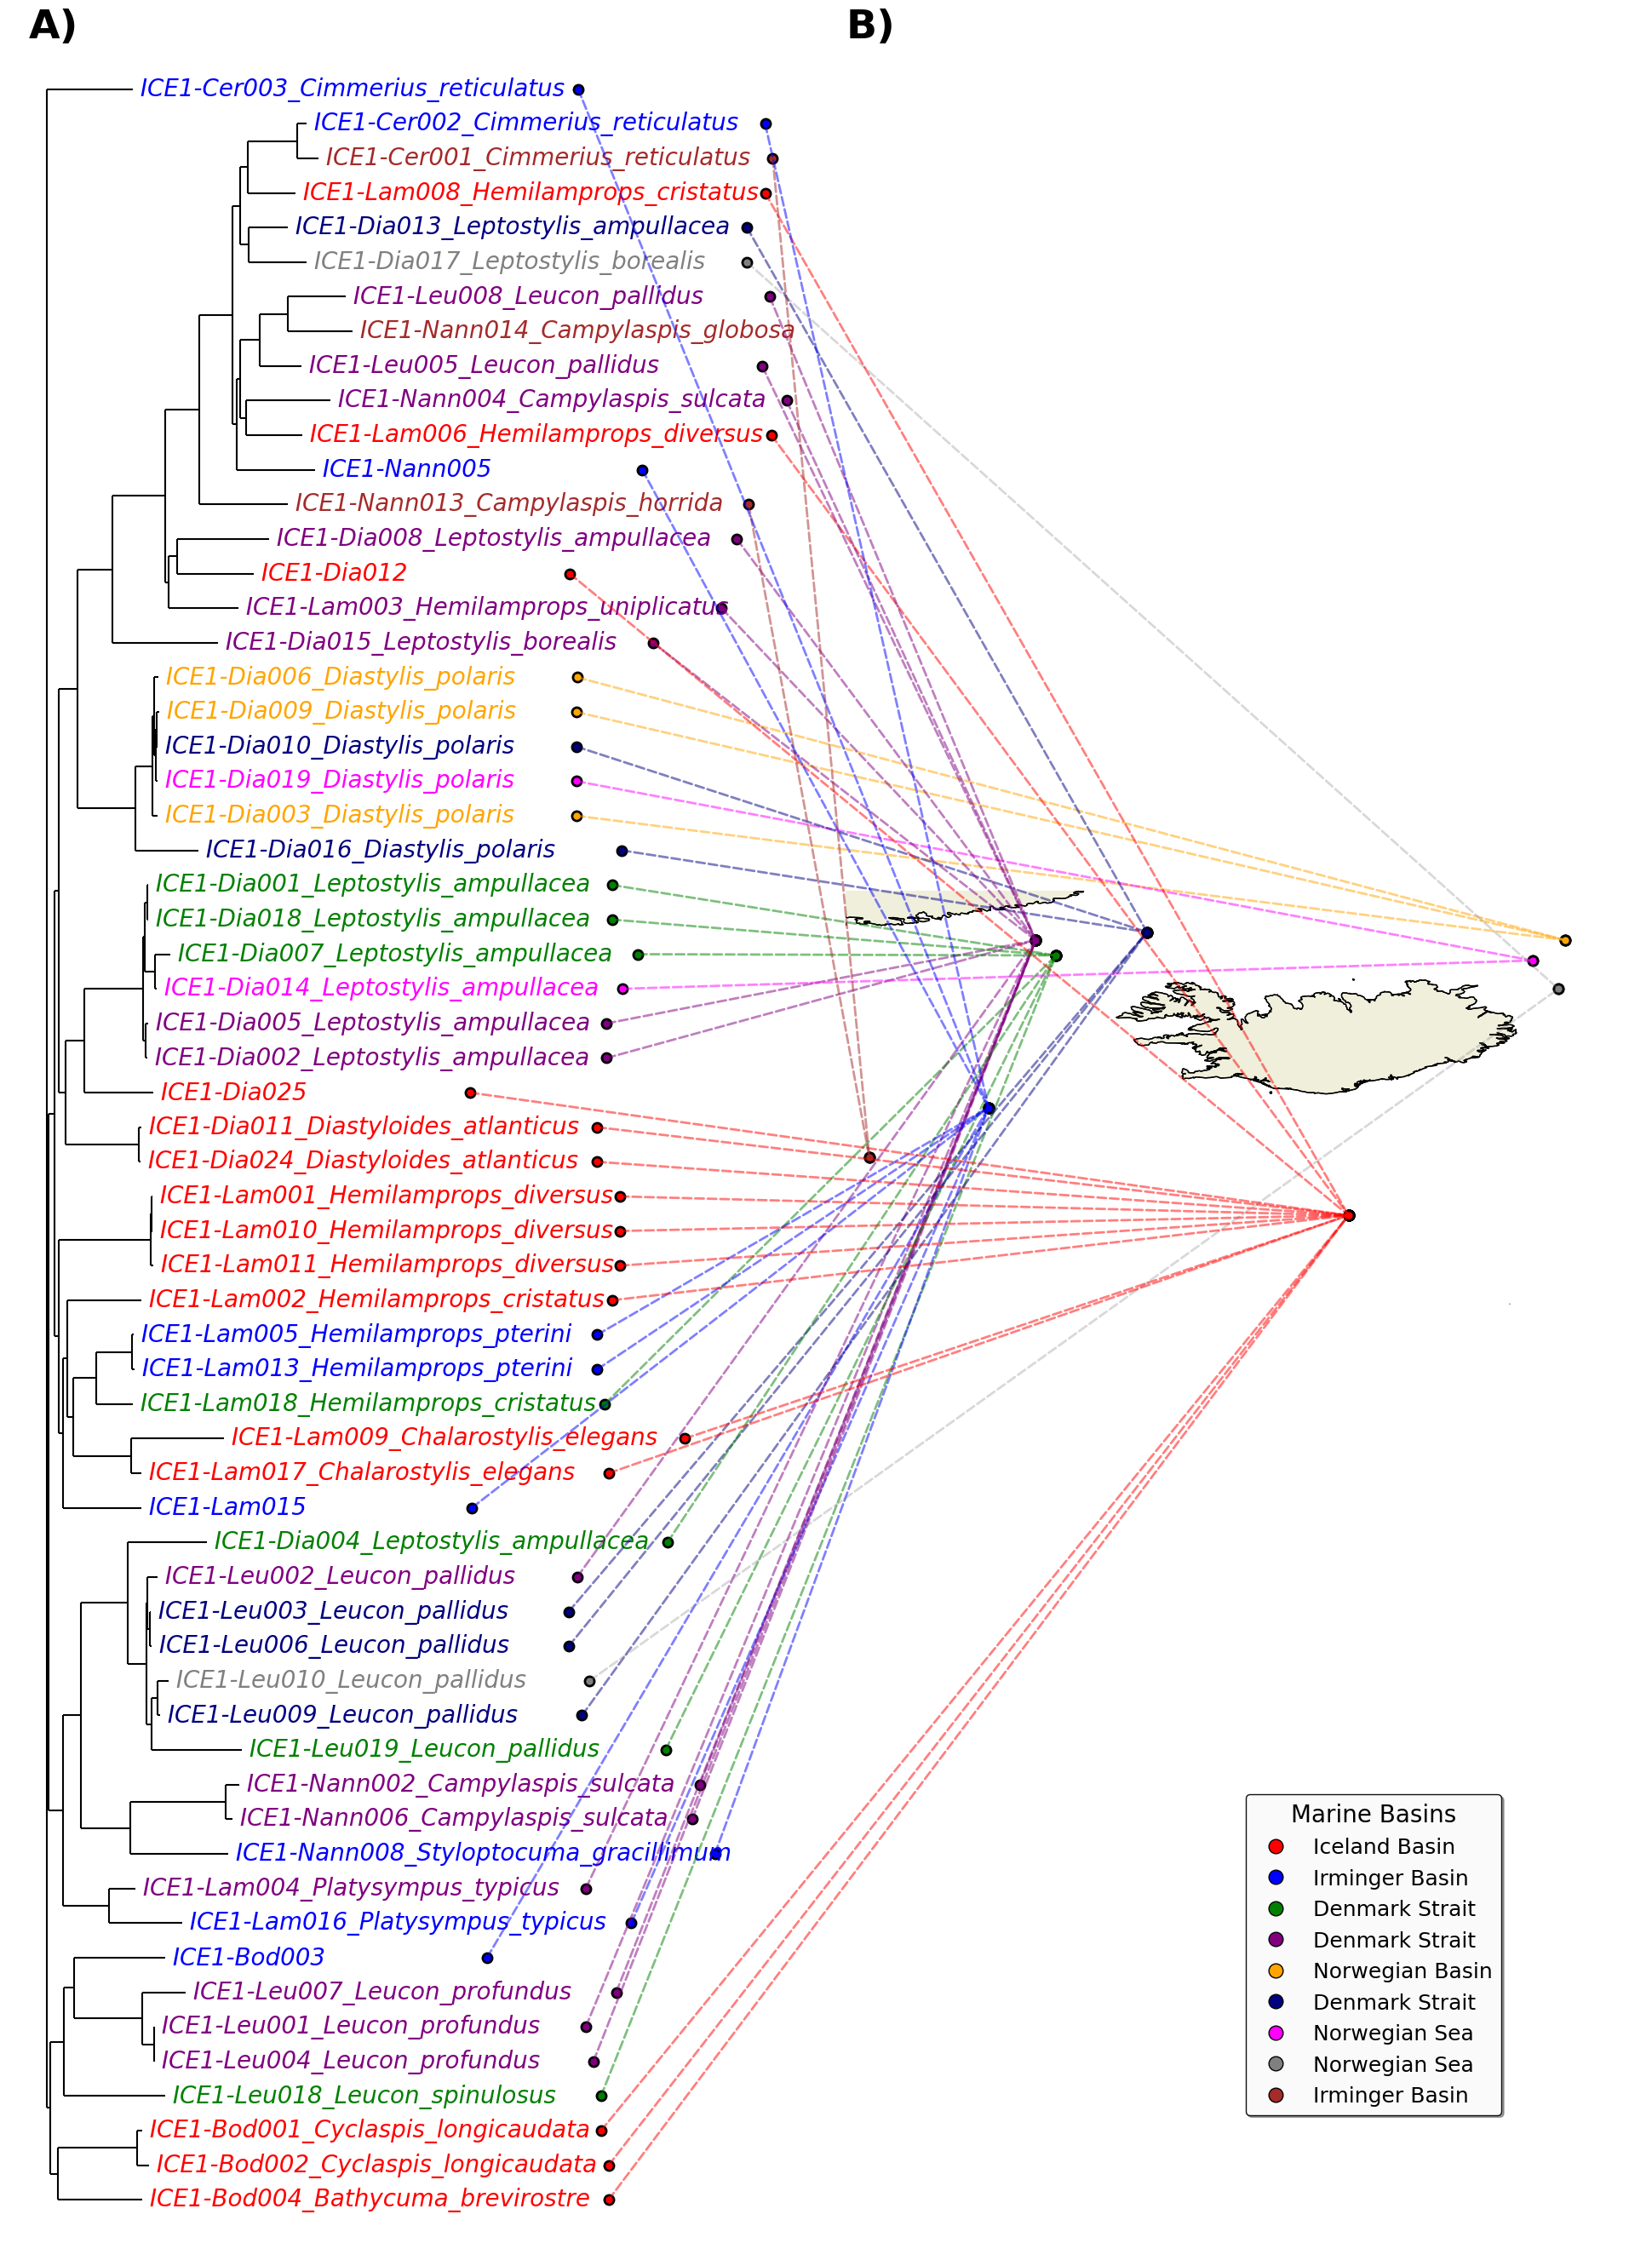

In [72]:
# Generate the plot
fig = plotter.plot(figsize=(24, 32))

print("\n✓ Visualization created successfully")
print(f"  Figure size: {fig.get_size_inches()} inches")
print(f"  DPI: {fig.dpi}")

## 7. Display the Plot

In [73]:
# Display the figure
plotter.show()

## 8. Save the Visualization

Export to SVG and PNG for publication.

In [74]:
# Save the figure
svg_file, png_file, pdf_file = plotter.save(output_dir=str(output_dir), prefix="cumacea")

print(f"\n✓ Figure saved successfully:")
print(f"  SVG: {svg_file}")
print(f"  PNG: {png_file}")
print(f"  PDF: {pdf_file}")


✓ Saved SVG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\cumacea_to_map_20260520_194109.svg
✓ Saved PNG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\cumacea_to_map_20260520_194109.png
✓ Saved PDF: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\cumacea_to_map_20260520_194109.pdf

✓ Figure saved successfully:
  SVG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\cumacea_to_map_20260520_194109.svg
  PNG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\cumacea_to_map_20260520_194109.png
  PDF: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\cumacea_to_map_20260520_194109.pdf


## 9. Alternative: Using Raster Layer

If you have bathymetric or environmental data, you can overlay it on the map.

In [75]:
# OPTIONAL: With raster layer (bathymetry, elevation, etc.)
# Uncomment and modify if you have a raster file

# raster_file = data_dir / "bathymetry.tif"

# plotter_with_raster = PhyloGeoPlotter(
#     nwk_file=str(nwk_file),
#     gps_file=str(gps_file),
#     offset_file=str(offset_file),
#     raster_file=str(raster_file),      # Add bathymetric data
#     raster_band=1,                     # Band to visualize
#     raster_cmap="viridis",            # Colormap for raster
#     raster_contrast="percentile",     # Contrast enhancement
#     extent=[-32, -10, 55, 69],
#     trait_name="Oceanic Sector",
#     color_map=color_map,
#     color_to_label=color_to_label,
#     legend_config=legend_config,
#     verbose=True,
# )

# fig_raster = plotter_with_raster.plot()
# plotter_with_raster.save(output_dir=str(output_dir), prefix="cumacea_with_raster")

## 10. GPS Data Format

Your GPS CSV should look like this (no color or sector columns needed):

In [76]:
import pandas as pd

# Load and inspect GPS data
gps_data = pd.read_csv(gps_file)
print("GPS Data Format:")
print(gps_data.head(10))
print(f"\nTotal records: {len(gps_data)}")
print(f"Columns: {list(gps_data.columns)}")
print(f"\nUnique trait_values: {sorted(gps_data['trait_value'].unique())}")
print(f"Trait value counts:\n{gps_data['trait_value'].value_counts().sort_index()}")

GPS Data Format:
                          specimen_id  longitude  latitude  trait_value
0  ICE1-Bod001_Cyclaspis_longicaudata    -18.136    60.046            1
1                         ICE1-Bod003    -28.068    63.018            2
2   ICE1-Bod004_Bathycuma_brevirostre    -18.136    60.046            1
3   ICE1-Cer002_Cimmerius_reticulatus    -28.068    63.018            2
4   ICE1-Cer003_Cimmerius_reticulatus    -28.068    63.018            2
5  ICE1-Dia001_Leptostylis_ampullacea    -26.207    67.215            3
6  ICE1-Dia004_Leptostylis_ampullacea    -26.207    67.215            3
7  ICE1-Dia005_Leptostylis_ampullacea    -26.767    67.633            4
8       ICE1-Dia006_Diastylis_polaris    -12.162    67.639            5
9  ICE1-Dia007_Leptostylis_ampullacea    -26.207    67.215            3

Total records: 62
Columns: ['specimen_id', 'longitude', 'latitude', 'trait_value']

Unique trait_values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int

## 11. Save Color Mappings as JSON (Optional)

For reproducibility and CLI usage, save your mappings to a JSON file.

In [77]:
# Save color mappings to JSON for reproducibility and CLI usage
color_config = {
    "color_map": {
        str(k): v for k, v in color_map.items()  # Convert int keys to strings for JSON
    },
    "color_to_label": color_to_label,
}

json_file = output_dir / "cumacea_colors.json"

with open(json_file, 'w') as f:
    json.dump(color_config, f, indent=2, ensure_ascii=False)

print(f"✓ Color mappings saved to: {json_file}")
print(f"\nFile contents:")
with open(json_file, 'r') as f:
    print(f.read())

✓ Color mappings saved to: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\cumacea_colors.json

File contents:
{
  "color_map": {
    "1": "red",
    "2": "blue",
    "3": "green",
    "4": "purple",
    "5": "orange",
    "6": "navy",
    "7": "magenta",
    "8": "grey",
    "9": "brown"
  },
  "color_to_label": {
    "red": "Iceland Basin",
    "blue": "Irminger Basin",
    "green": "Denmark Strait",
    "purple": "Denmark Strait",
    "orange": "Norwegian Basin",
    "navy": "Denmark Strait",
    "magenta": "Norwegian Sea",
    "grey": "Norwegian Sea",
    "brown": "Irminger Basin"
  }
}


## 12. CLI Equivalent

This Jupyter workflow can be replicated from the command line:

In [78]:
# Equivalent command-line usage:
# python tree_to_map_raster.py \
#   --nwk data/cumacea.nwk \
#   --gps data/cumacea_gps.csv \
#   --offset data/cumacea_offsets.csv \
#   --extent -32 -10 55 69 \
#   --color-map-file output/cumacea_colors.json \
#   --show-legend \
#   --legend-title "Marine Basins" \
#   --legend-loc "lower left" \
#   --trait-name "Oceanic Sector" \
#   --output output

print("See CLI_COLOR_MAPPING_GUIDE.md for command-line usage examples")

See CLI_COLOR_MAPPING_GUIDE.md for command-line usage examples


## 13. Summary

### What We Created:
- ✅ Phylogeographic visualization of 62 Cumacea species
- ✅ Categorical legend showing oceanic sectors (colors)
- ✅ Connection lines linking phylogenetic tree to geographic locations
- ✅ High-resolution output (SVG + PNG)

### Key Points:
- **GPS CSV**: Only needs `specimen_id`, `longitude`, `latitude`, `trait_value` columns
- **Color Mapping**: Separate dictionaries keep data clean and visualization flexible
- **Reproducibility**: All parameters documented and saveable as JSON
- **No Colorbar**: Automatically hidden when using categorical legend

### Next Steps:
1. Modify color mappings for your specific sectors
2. Adjust legend position and styling as needed
3. Add raster layer (bathymetry, temperature, etc.) if available
4. Export colors.json for command-line reproducibility